#### 0. Importar librerias

In [54]:
import pandas as pd
import sklearn
import missingno as mo
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree,_tree
import matplotlib.pyplot as plt

#### 1. Cargar e inspeccionar los datos

In [2]:
df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')

In [3]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,mes_checkin,cluster,cluster_0,cluster_1,cluster_2
0,2022-11-26 16:10:00,2023-01-01,2023-01-02 12:00:00,36,1,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
1,2022-12-21 17:27:00,2023-01-01,2023-01-10 12:00:00,11,9,January,Sunday,1,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
2,2022-09-21 19:46:00,2023-01-01,2023-01-07 12:00:00,102,6,January,Sunday,2,4,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
3,2022-09-24 12:09:00,2023-01-01,2023-01-02 12:00:00,99,1,January,Sunday,2,2,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1
4,2022-10-18 07:12:00,2023-01-01,2023-01-02 12:00:00,75,1,January,Sunday,4,0,channel_manager,...,30.0,98.0,23:59,27.0,Varias,1,2,0,0,1


In [4]:
df.columns

Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time', 'ciudad', 'mes_cancelacion',
       'estacion_cancelacion', 'mes_estancia', 'estacion_estancia',
       'mes_reserva', 'estacion_reserva', 'dia_semana_reserva',
       'dia_semana_reserva_nombre', 'dia_semana_cancelacion',
       'dia_semana_cancelacion_nombre', 'dia_sem

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52004 entries, 0 to 52003
Data columns (total 86 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   booked_at                       52004 non-null  object 
 1   checkin_time                    52004 non-null  object 
 2   checkout_time                   52004 non-null  object 
 3   lead_time                       52004 non-null  int64  
 4   lenght_of_stay                  52004 non-null  int64  
 5   checkin_month                   52004 non-null  object 
 6   checkin_day                     52004 non-null  object 
 7   adult_count                     52004 non-null  int64  
 8   child_count                     52004 non-null  int64  
 9   origin                          52004 non-null  object 
 10  travel_agency_name              52004 non-null  object 
 11  requested_category              52004 non-null  object 
 12  requested_category_name         

In [6]:
df.shape

(52004, 86)

<Axes: >

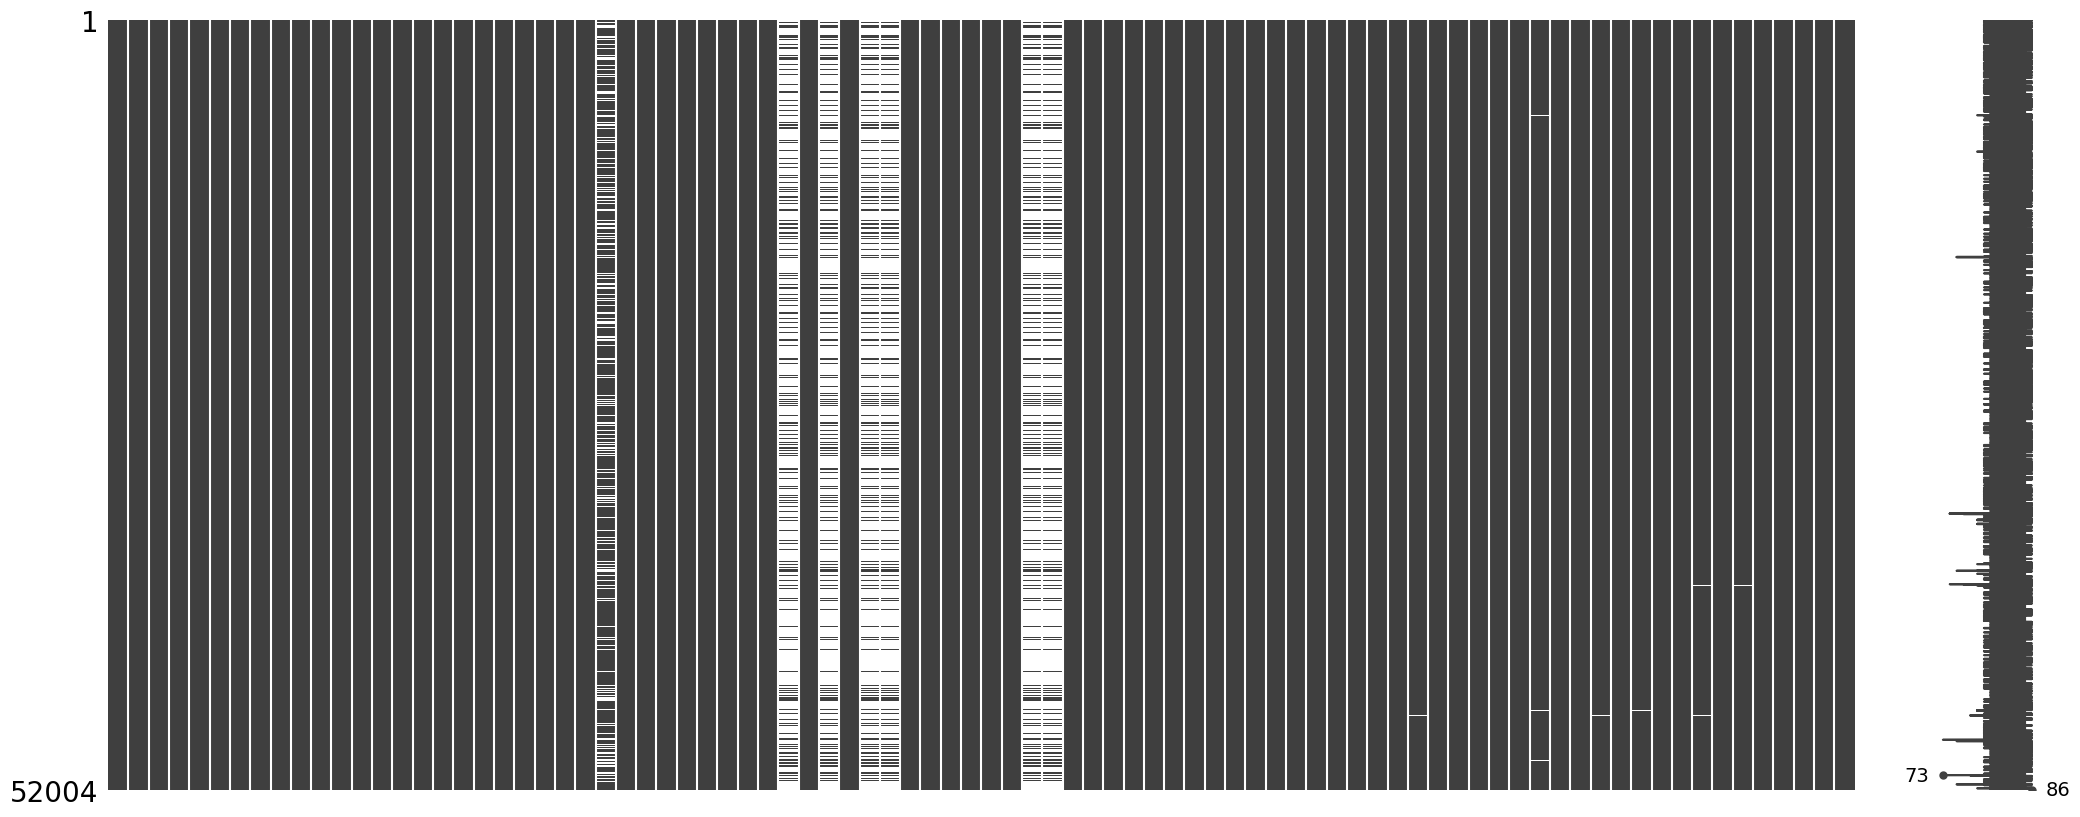

In [7]:
mo.matrix(df)

#### 2. Seleccion de variables relevantes para modelado

In [8]:
# Criterio para la seleccion de variables para regresion:
#    1. Primero se seleccionan únicamente variables disponibles en el momento de la reserva y que, desde el punto de vista de negocio, puedan influir en la probabilidad de cancelación.
#    2. Después mirar la relacion entre cada una de ellas con el target:
#       - para las numericas con corr
#       - para las binarias media del target
#       - para las categoricas la tasa de cancelacion por grupo (si se acaba seleccionando pasar a dummies)
#    3. Entre las seleccionadas, eliminar las que tengan alta correlacion entre ellas

In [9]:
# Definir el target
df['target'] = (df['status'] == 'cancelled').astype(int)

df['target'].value_counts(normalize=True) # 76% no cancelan

target
0    0.764018
1    0.235982
Name: proportion, dtype: float64

In [10]:
# 1. Seleccion conceptual
vars_numericas = ['lead_time', 'lenght_of_stay', 
                  'adult_count', 'child_count',
                  'available_units', 'reservation_net_value', 
                  'total_adr', 'product_count', 
                  'recurrence', 'ratio_cancelacion_mes_estancia', 
                  'tmed', 'prec', 'sol']

vars_binarias = ['zona_roja','es_finde',
                 'es_festivo', 'cluster_1',
                 'cluster_2']

vars_categoricas = ['origin', 'business_segment',
                    'rate_type', 'requested_category', 
                    'asset_type', 'brand', 'ciudad']

In [11]:
#2. Analisis de relacion con el target

# 2.1 Numericas
corr_num = (
    df[vars_numericas + ['target']]
    .corr()['target']
    .sort_values(ascending=False)
    .drop('target'))

print(corr_num)


lead_time                         0.220967
lenght_of_stay                    0.131798
adult_count                       0.101525
reservation_net_value             0.086955
total_adr                         0.053947
ratio_cancelacion_mes_estancia    0.025349
prec                              0.013570
child_count                      -0.006512
available_units                  -0.012650
sol                              -0.020129
tmed                             -0.025851
recurrence                       -0.046127
product_count                    -0.135070
Name: target, dtype: float64


In [12]:
# Nos quedamos con |corr| >= 0.05 y 1, porque aun que sean correlaciones debiles, al tratarse de cancelaciones y de comportamiento humano,
# 0.10 ya es bastante y 0.05 puede ser útil combinado con otras variables
vars_numericas_filtradas = corr_num[corr_num.abs() >= 0.05].index.tolist()
print(vars_numericas_filtradas)

['lead_time', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'total_adr', 'product_count']


In [13]:
# Mirar si hay alta correlacion entre las numericas (para evitar multicolinealidad)
print(df[vars_numericas_filtradas].corr()) # Ninguna supera un valor critico (~0.7), asi que no eliminamos ninguna

                       lead_time  lenght_of_stay  adult_count  \
lead_time               1.000000        0.098732     0.220131   
lenght_of_stay          0.098732        1.000000    -0.030339   
adult_count             0.220131       -0.030339     1.000000   
reservation_net_value   0.176664        0.448822     0.330383   
total_adr               0.134558       -0.078498     0.526133   
product_count           0.105714        0.121244     0.032290   

                       reservation_net_value  total_adr  product_count  
lead_time                           0.176664   0.134558       0.105714  
lenght_of_stay                      0.448822  -0.078498       0.121244  
adult_count                         0.330383   0.526133       0.032290  
reservation_net_value               1.000000   0.626397       0.307983  
total_adr                           0.626397   1.000000       0.190920  
product_count                       0.307983   0.190920       1.000000  


In [14]:
# 2.2 Binarias
for var in vars_binarias:
    print(f'\n{var}')
    print(df.groupby(var)['target'].mean())


zona_roja
zona_roja
0    0.230250
1    0.249437
Name: target, dtype: float64

es_finde
es_finde
0    0.229869
1    0.251552
Name: target, dtype: float64

es_festivo
es_festivo
0    0.236251
1    0.227094
Name: target, dtype: float64

cluster_1
cluster_1
0    0.232667
1    0.241563
Name: target, dtype: float64

cluster_2
cluster_2
0    0.241056
1    0.228008
Name: target, dtype: float64


In [15]:
# Para las variables binarias un umbral razonable de diferencia puede ser mayor que 0.02
vars_binarias_filtradas = []

for var in vars_binarias:
    medias = df.groupby(var)['target'].mean()
    diff = abs(medias[1] - medias[0])
    if diff > 0.02:
        vars_binarias_filtradas.append(var)

print(vars_binarias_filtradas)

['es_finde']


In [16]:
# 2.3 Categoricas
for var in vars_categoricas:
    print(f'\n{var}')
    display(
        df.groupby(var)['target']
        .mean()
        .sort_values(ascending=False)
        .head(10))


origin


origin
email              0.420612
telephone          0.302963
in_person          0.301370
channel_manager    0.240168
direct_channel     0.136554
Name: target, dtype: float64


business_segment


business_segment
Travel Individual      0.474332
Business Individual    0.440613
Mid Stay               0.365385
Travel Group           0.342903
MICE Group             0.321063
MICE Individual        0.276471
Leisure Group          0.236181
Leisure Individual     0.219563
Business Group         0.149533
Name: target, dtype: float64


rate_type


...

asset_type
apartment     0.241563
aparthotel    0.240264
hostel        0.228008
Name: target, dtype: float64


brand


brand
koisi     0.259020
libere    0.230342
Name: target, dtype: float64


ciudad


ciudad
Valencia    0.285312
Granada     0.271475
Donosti     0.259020
Bilbao      0.253384
Vitoria     0.240264
Madrid      0.227432
Pamplona    0.219519
Málaga      0.217810
Córdoba     0.196279
Name: target, dtype: float64

In [17]:
vars_categoricas_filtradas = []

for var in vars_categoricas:
    medias = df.groupby(var)['target'].mean()
    diff = medias.max() - medias.min()
    if diff >= 0.03:
        vars_categoricas_filtradas.append(var)

print(vars_categoricas_filtradas) 


['origin', 'business_segment', 'rate_type', 'requested_category', 'ciudad']


In [18]:
# Crear el df para modelado con las variables seleccionadas
df_modelo = df[vars_numericas_filtradas + vars_binarias_filtradas + vars_categoricas_filtradas + ['target']]

df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52004 entries, 0 to 52003
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lead_time              52004 non-null  int64  
 1   lenght_of_stay         52004 non-null  int64  
 2   adult_count            52004 non-null  int64  
 3   reservation_net_value  52004 non-null  float64
 4   total_adr              52004 non-null  float64
 5   product_count          52004 non-null  int64  
 6   es_finde               52004 non-null  int64  
 7   origin                 52004 non-null  object 
 8   business_segment       52004 non-null  object 
 9   rate_type              52004 non-null  object 
 10  requested_category     52004 non-null  object 
 11  ciudad                 52004 non-null  object 
 12  target                 52004 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.2+ MB


#### 3. Separar train / test

In [19]:
# Primero separar X (variables explicativas) e Y (target)
X = df_modelo.drop(columns='target')
Y = df_modelo['target']

# Separar train y test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y) # stratify=Y asegura que train y test tengan la misma propocion de clases que el df original, importante porque el target esta desbalanceado (76% no cancelan)

# Separar las variables por numericas binarias y categoricas para preprocesar cada una de una manera
# Numéricas
X_train_num = X_train[vars_numericas_filtradas]
X_test_num = X_test[vars_numericas_filtradas]

# Binarias (ya son 0/1)
X_train_bin = X_train[vars_binarias_filtradas]
X_test_bin = X_test[vars_binarias_filtradas]

In [20]:
# Ahora dummificar las variables categoricas seleccionadas
ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore')

# Fit SOLO con train
X_train_cat = ohe.fit_transform(X_train[vars_categoricas_filtradas]).toarray()
X_test_cat = ohe.transform(X_test[vars_categoricas_filtradas]).toarray()

# Convertir a data frame
cat_cols = ohe.get_feature_names_out(vars_categoricas_filtradas)

X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_cols, index=X_test.index)

In [21]:
# Concatenar todas las variables
X_train = pd.concat(
    [X_train_num, X_train_bin, X_train_cat],
    axis=1)

X_test = pd.concat(
    [X_test_num, X_test_bin, X_test_cat],
    axis=1)

#### 4. Escalar las variables numéricas continuas

In [22]:
# Escalar solo numéricas
scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[vars_numericas_filtradas]),
    columns=vars_numericas_filtradas,
    index=X_train.index)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test[vars_numericas_filtradas]),
    columns=vars_numericas_filtradas,
    index=X_test.index)

# Variables no numéricas: binarias + todas las dummies restantes
vars_no_num = [c for c in X_train.columns if c not in vars_numericas_filtradas]

X_train_scaled = pd.concat([X_train_num_scaled, X_train[vars_no_num]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled, X_test[vars_no_num]], axis=1)

X_train_scaled.head()

,lead_time,lenght_of_stay,adult_count,reservation_net_value,total_adr,product_count,es_finde,origin_direct_channel,origin_email,origin_in_person,...,requested_category_Two bedroom apartment,requested_category_Two bedroom apartment superior,ciudad_Córdoba,ciudad_Donosti,ciudad_Granada,ciudad_Madrid,ciudad_Málaga,ciudad_Pamplona,ciudad_Valencia,ciudad_Vitoria
41843,-0.361290,-0.516266,-0.090815,-0.497832,0.103213,0.195030,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50805,-0.439162,0.777580,-0.090815,1.191504,0.141446,2.328713,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1397,-0.497565,-0.516266,-0.846267,-0.786575,-0.675125,-0.516198,1,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
24592,4.564071,-0.516266,2.930993,-0.422618,0.305960,-0.516198,0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18914,-0.322355,-0.516266,-0.846267,-0.689257,-0.412795,-0.516198,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
# Aplicar SMOTE a train para probar
smote = SMOTE(random_state=42)
X_train_res, Y_train_res = smote.fit_resample(X_train_scaled, Y_train)

c:\conda_envs\reto06_VerdeOscuro\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


#### 5. Entrenar modelo de Regresión Logística

              precision    recall  f1-score   support

           0     0.8732    0.7779    0.8228     11920
           1     0.4687    0.6342    0.5390      3682

    accuracy                         0.7440     15602
   macro avg     0.6709    0.7061    0.6809     15602
weighted avg     0.7777    0.7440    0.7558     15602



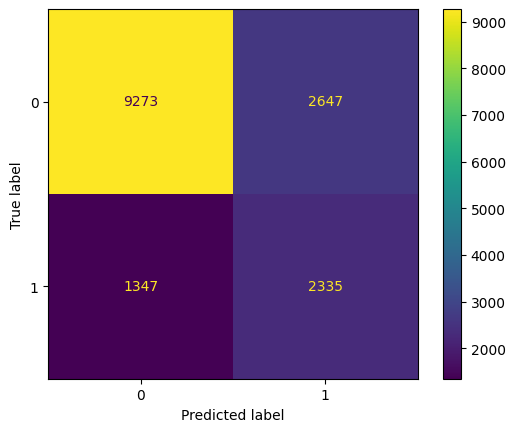

In [24]:
# Modelo
modelo_reg_log = LogisticRegression(max_iter=10000, class_weight='balanced', l1_ratio=0.5, solver='saga')
modelo_reg_log.fit(X_train_scaled, Y_train)

#Predicciones
y_prob = modelo_reg_log.predict_proba(X_test_scaled)[:,1]
y_pred = (y_prob >= 0.55).astype(int)

# Metricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [25]:
# Ver cual es el mejor valor de probabilidad y ajustar
thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh, best_f1 = 0.5, 0

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    f1 = f1_score(Y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Mejor threshold:", best_thresh, "con F1:", best_f1)

Mejor threshold: 0.5499999999999998 con F1: 0.5390120036934442


In [26]:
def evaluar_modelo(nombre, y_test, y_pred, y_prob, resultados):
    report = classification_report(y_test, y_pred, output_dict=True)

    resultados.append({
        'Modelo': nombre,
        'F1_canceladas': report['1']['f1-score'],
        'Recall_canceladas': report['1']['recall'],
        'Precision_canceladas': report['1']['precision'],
        'ROC_AUC': roc_auc_score(y_test, y_prob)
    })

In [27]:
resultados = []

evaluar_modelo(
    nombre='Regresión logística',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.8732    0.7779    0.8228     11920
           1     0.4687    0.6342    0.5390      3682

    accuracy                         0.7440     15602
   macro avg     0.6709    0.7061    0.6809     15602
weighted avg     0.7777    0.7440    0.7558     15602



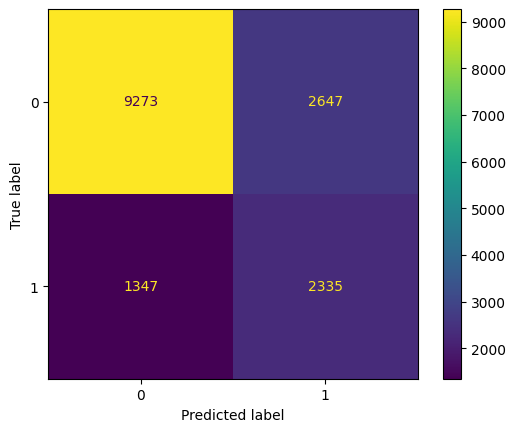

In [28]:
# Regresión Logística con SMOTE

# Modelo
modelo_reg_log_res = LogisticRegression(max_iter=10000, class_weight='balanced', l1_ratio=0.5, solver='saga')
modelo_reg_log_res.fit(X_train_res, Y_train_res)

#Predicciones
y_prob = modelo_reg_log.predict_proba(X_test_scaled)[:,1]
y_pred = (y_prob >= 0.55).astype(int)

# Metricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [29]:
evaluar_modelo(
    nombre='Regresión logística SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

In [30]:
# Probar StratifiedKFold con regresion logistica
# Consiste en dividir los datos en k partes (folds). Luego, entrenas el modelo k veces: cada vez usas k-1 partes para entrenar y la parte restante para probar. Al final, se promedian las métricas de todas las iteraciones.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5 folds

f1_scores = []
roc_scores = []

for train_index, test_index in skf.split(X, Y):
    
    # Modelo
    model = LogisticRegression(C = 0.1, max_iter=1000, class_weight='balanced', l1_ratio=0, solver='saga')
    model.fit(X_train_scaled, Y_train)
    
    # Predicciones
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    y_pred = (y_prob >= 0.55).astype(int)
    
    # Métricas
    f1_scores.append(f1_score(Y_test, y_pred))
    roc_scores.append(roc_auc_score(Y_test, y_prob))

print("F1-score promedio:", np.mean(f1_scores))
print("ROC AUC promedio:", np.mean(roc_scores))

F1-score promedio: 0.5387726799953774
ROC AUC promedio: 0.7680466303511734


#### 6. Entrenar modelo SVM

              precision    recall  f1-score   support

           0     0.8975    0.7853    0.8377     11920
           1     0.5052    0.7097    0.5902      3682

    accuracy                         0.7675     15602
   macro avg     0.7014    0.7475    0.7140     15602
weighted avg     0.8049    0.7675    0.7793     15602



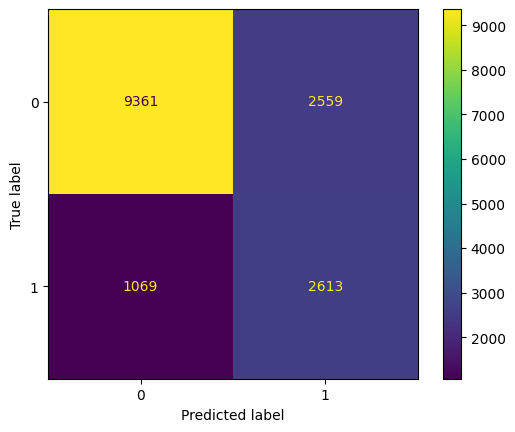

In [31]:
# Modelo 
svm = SVC(kernel='rbf', 
          C=1,
          gamma='scale',
          class_weight='balanced',
          probability=True,
          random_state=42)

# Entrenarlo
svm.fit(X_train_scaled, Y_train)

# Predicciones
y_prob = svm.predict_proba(X_test_scaled)[:, 1]
y_pred = svm.predict(X_test_scaled)

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [32]:
evaluar_modelo(
    nombre='SVM',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.8968    0.7929    0.8416     11920
           1     0.5123    0.7045    0.5933      3682

    accuracy                         0.7720     15602
   macro avg     0.7046    0.7487    0.7174     15602
weighted avg     0.8060    0.7720    0.7830     15602



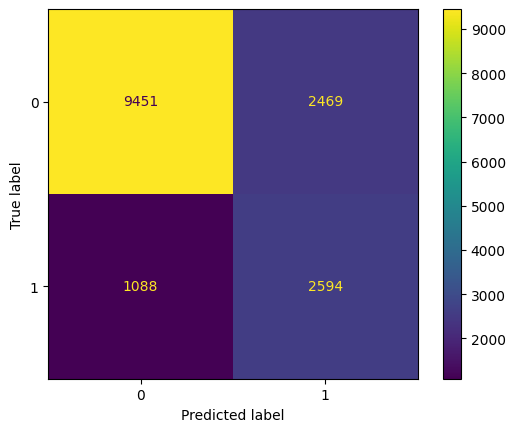

In [33]:
# Probar con SMOTE

# Modelo 
svm = SVC(kernel='rbf', 
          C=1,
          gamma='scale',
          class_weight='balanced',
          probability=True,
          random_state=42)

# Entrenarlo
svm.fit(X_train_res, Y_train_res)

# Predicciones
y_prob = svm.predict_proba(X_test_scaled)[:, 1]
y_pred = svm.predict(X_test_scaled)

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [34]:
evaluar_modelo(
    nombre='SVM SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

F1: 0.527468152866242
              precision    recall  f1-score   support

           0     0.8883    0.6883    0.7756     11920
           1     0.4163    0.7197    0.5275      3682

    accuracy                         0.6957     15602
   macro avg     0.6523    0.7040    0.6515     15602
weighted avg     0.7769    0.6957    0.7170     15602



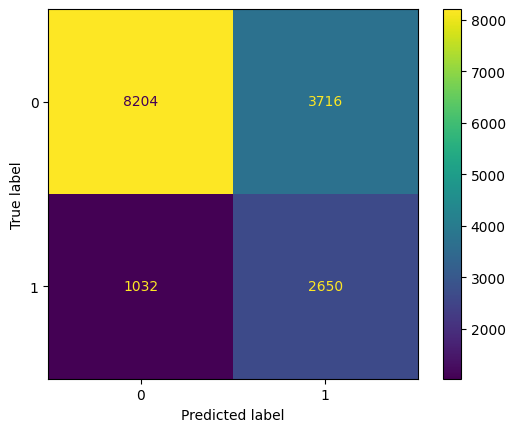

In [30]:
# SVM lineal
svm_linear = LinearSVC(
    C=1,
    class_weight='balanced',
    random_state=42,
    max_iter=5000)

svm_linear.fit(X_train_scaled, Y_train)
y_pred = svm_linear.predict(X_test_scaled)

print("F1:", f1_score(Y_test, y_pred))

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [31]:
evaluar_modelo(
    nombre='SVM Lineal',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

F1: 0.5210629921259843
              precision    recall  f1-score   support

           0     0.8866    0.6786    0.7688     11920
           1     0.4086    0.7189    0.5211      3682

    accuracy                         0.6881     15602
   macro avg     0.6476    0.6988    0.6449     15602
weighted avg     0.7738    0.6881    0.7103     15602



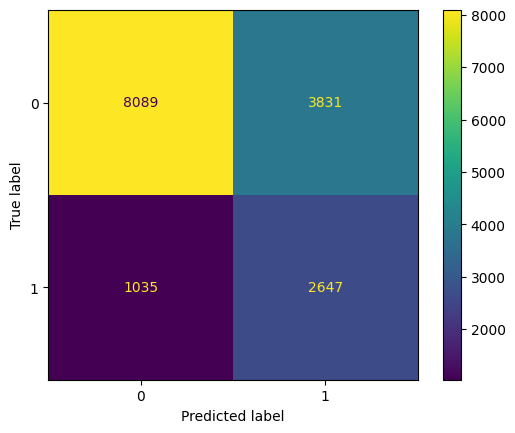

In [32]:
# SVM lineal
svm_linear_res = LinearSVC(
    C=1,
    class_weight='balanced',
    random_state=42,
    max_iter=5000)

svm_linear_res.fit(X_train_res, Y_train_res)
y_pred = svm_linear_res.predict(X_test_scaled)

print("F1:", f1_score(Y_test, y_pred))

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [33]:
evaluar_modelo(
    nombre='SVM Lineal SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 7. Entrenar modelo Naive

              precision    recall  f1-score   support

           0     0.7922    0.8892    0.8379     11920
           1     0.4058    0.2450    0.3055      3682

    accuracy                         0.7371     15602
   macro avg     0.5990    0.5671    0.5717     15602
weighted avg     0.7010    0.7371    0.7123     15602



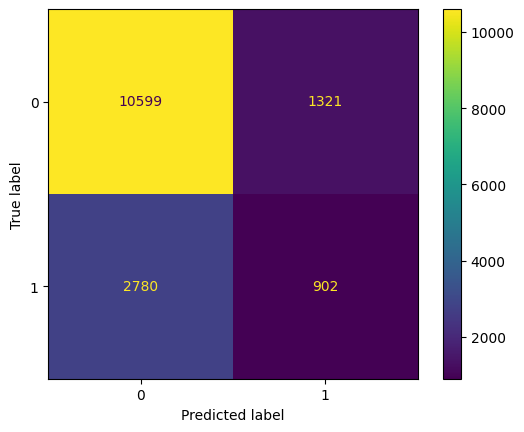

In [34]:
# Modelo
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)

# Predicciones
y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [35]:
evaluar_modelo(
    nombre='Naive Bayes',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.7922    0.8892    0.8379     11920
           1     0.4058    0.2450    0.3055      3682

    accuracy                         0.7371     15602
   macro avg     0.5990    0.5671    0.5717     15602
weighted avg     0.7010    0.7371    0.7123     15602



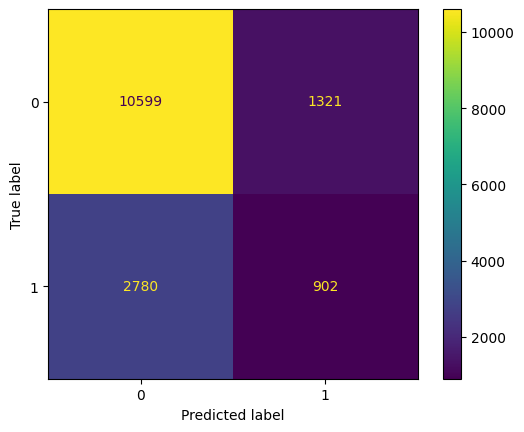

In [36]:
# Probar Niave Bayes con SMOTE

# Modelo
nb_model_res = GaussianNB()
nb_model_res.fit(X_train_res, Y_train_res)

# Predicciones
y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [37]:
evaluar_modelo(
    nombre='Naive Bayes SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 8. Entrenar modelo Random Forest

              precision    recall  f1-score   support

           0     0.8585    0.9304    0.8930     11920
           1     0.6908    0.5035    0.5825      3682

    accuracy                         0.8296     15602
   macro avg     0.7746    0.7169    0.7377     15602
weighted avg     0.8189    0.8296    0.8197     15602



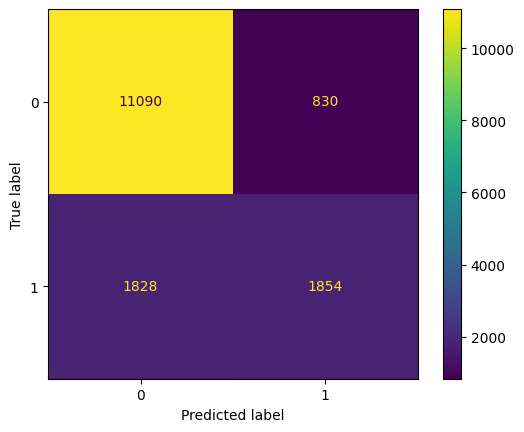

In [38]:
# Crear el modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,      # Número de árboles
    max_depth=None,        # Profundidad máxima de los árboles (None = expandir hasta hojas puras)
    class_weight='balanced', # Ajusta pesos por desbalance de clases
    random_state=42,
    n_jobs=-1,              # Usar todos los núcleos de la CPU
    max_features='log2',
    min_samples_leaf=1
)

# Entrenar el modelo
rf_model.fit(X_train, Y_train)

# Predicciones
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [39]:
evaluar_modelo(
    nombre='Random Forest',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

              precision    recall  f1-score   support

           0     0.8837    0.8763    0.8800     11920
           1     0.6102    0.6266    0.6183      3682

    accuracy                         0.8174     15602
   macro avg     0.7469    0.7515    0.7491     15602
weighted avg     0.8191    0.8174    0.8182     15602



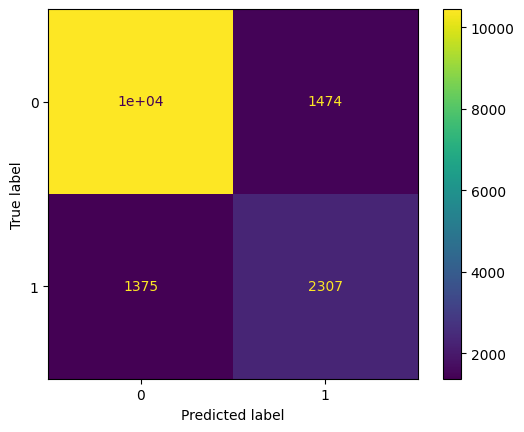

In [40]:
# Random Forest con SMOTE

# Modelo
rf_model = RandomForestClassifier(
    n_estimators=300,      # Número de árboles
    max_depth=None,        # Profundidad máxima de los árboles (None = expandir hasta hojas puras)
    class_weight='balanced', # Ajusta pesos por desbalance de clases
    random_state=42,
    n_jobs=-1              # Usar todos los núcleos de la CPU
)

# Entrenar el modelo
rf_model.fit(X_train_res, Y_train_res)

# Predicciones
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [41]:
evaluar_modelo(
    nombre='Random Forest SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 9. Entrenar modelo Arbol de Decisión

F1-score (canceladas): 0.5588113050706567
ROC AUC: 0.7807270154278568
              precision    recall  f1-score   support

           0     0.8972    0.7271    0.8032     11920
           1     0.4525    0.7303    0.5588      3682

    accuracy                         0.7279     15602
   macro avg     0.6749    0.7287    0.6810     15602
weighted avg     0.7923    0.7279    0.7456     15602



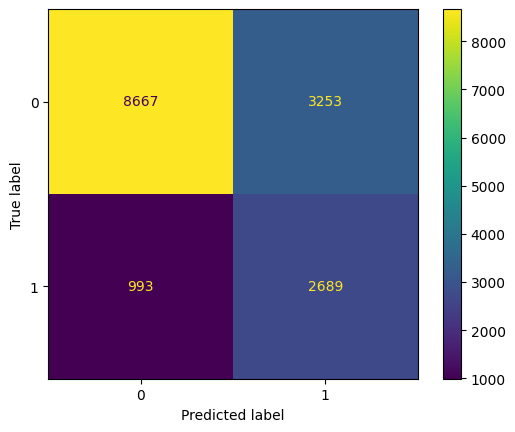

In [47]:
# Modelo
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_leaf=100,
    class_weight='balanced')

# Entrenar modelo
dt.fit(X_train, Y_train)

# Predicciones
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

# Metricas
f1 = f1_score(Y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(Y_test, y_proba)

print("F1-score (canceladas):", f1)
print("ROC AUC:", roc_auc)

print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [48]:
evaluar_modelo(
    nombre='Decision Tree',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

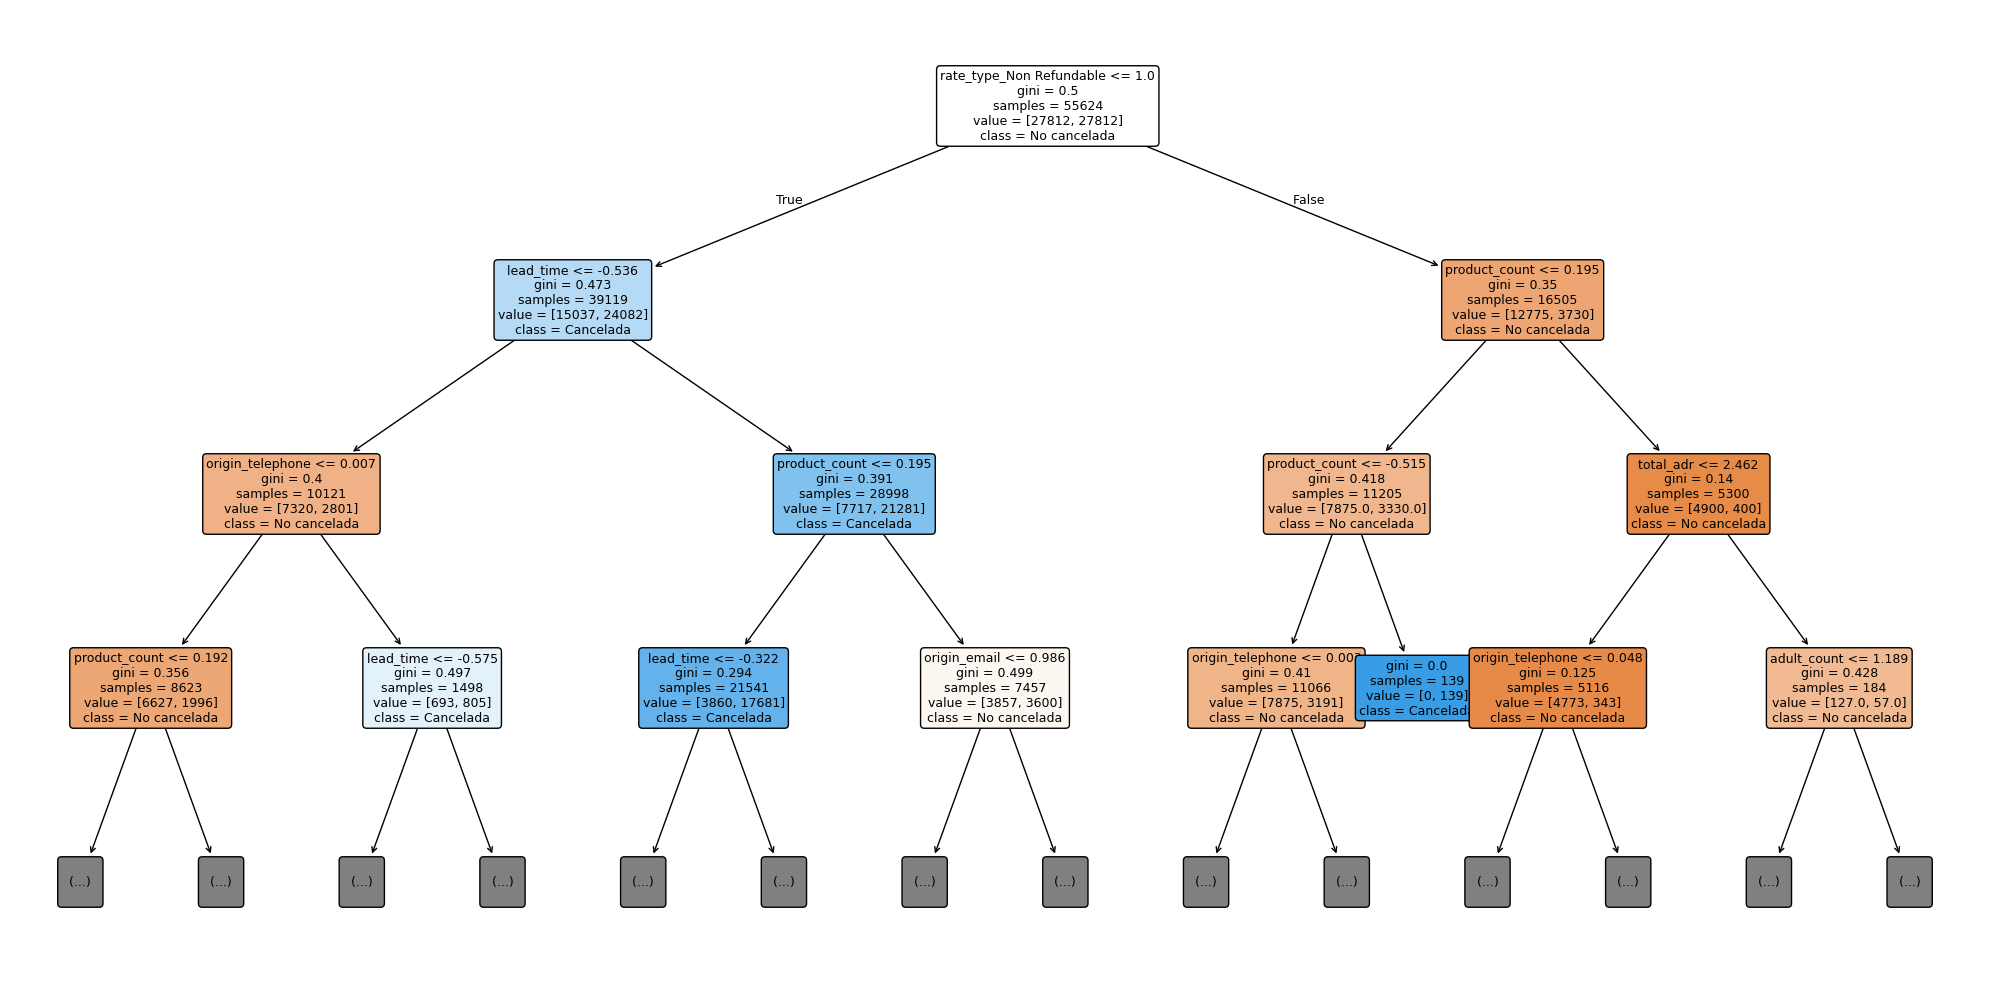

In [59]:
# Dibujar arbol de decision
# Se muestra únicamente una versión simplificada del Árbol de Decisión, 
# limitada a los primeros niveles, con el objetivo de facilitar la interpretación de los principales patrones detectados por el modelo.

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["No cancelada", "Cancelada"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9)

plt.tight_layout()
plt.show()


In [55]:
# Extraer regalas del arbol

# Definir la función
def extraer_reglas(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    reglas = []

    def recorrer(nodo, regla):
        if tree_.feature[nodo] != _tree.TREE_UNDEFINED:
            nombre = feature_name[nodo]
            umbral = tree_.threshold[nodo]

            recorrer(tree_.children_left[nodo],
                     regla + [f"{nombre} <= {umbral:.2f}"])
            recorrer(tree_.children_right[nodo],
                     regla + [f"{nombre} > {umbral:.2f}"])
        else:
            value = tree_.value[nodo][0]
            total = value.sum()
            prob_cancel = value[1] / total
            reglas.append((regla, prob_cancel, int(total)))

    recorrer(0, [])
    return reglas

# 
reglas = extraer_reglas(dt, X_train.columns)

reglas_alto_riesgo = sorted(reglas, key=lambda x: x[1], reverse=True)

for r in reglas_alto_riesgo[:5]:
    print("SI", " Y ".join(r[0]))
    print(f"→ Prob. cancelación ≈ {r[1]:.2f} (n={r[2]})\n")

SI rate_type_Non Refundable <= 1.00 Y lead_time <= -0.54 Y origin_telephone <= 0.01 Y product_count <= 0.19 Y product_count > -0.51
→ Prob. cancelación ≈ 1.00 (n=1)

SI rate_type_Non Refundable <= 1.00 Y lead_time <= -0.54 Y origin_telephone > 0.01 Y lead_time > -0.58 Y lead_time <= -0.56
→ Prob. cancelación ≈ 1.00 (n=1)

SI rate_type_Non Refundable <= 1.00 Y lead_time > -0.54 Y product_count <= 0.19 Y lead_time <= -0.32 Y rate_type_Non Refundable > 0.00
→ Prob. cancelación ≈ 1.00 (n=1)

SI rate_type_Non Refundable <= 1.00 Y lead_time > -0.54 Y product_count > 0.19 Y origin_email <= 0.99 Y rate_type_Non Refundable > 0.00
→ Prob. cancelación ≈ 1.00 (n=1)

SI rate_type_Non Refundable > 1.00 Y product_count <= 0.19 Y product_count <= -0.52 Y origin_telephone > 0.00 Y origin_telephone <= 1.00
→ Prob. cancelación ≈ 1.00 (n=1)



F1-score (canceladas): 0.55451518934665
ROC AUC: 0.7819899615944064
              precision    recall  f1-score   support

           0     0.8949    0.7261    0.8017     11920
           1     0.4494    0.7238    0.5545      3682

    accuracy                         0.7255     15602
   macro avg     0.6721    0.7249    0.6781     15602
weighted avg     0.7897    0.7255    0.7434     15602



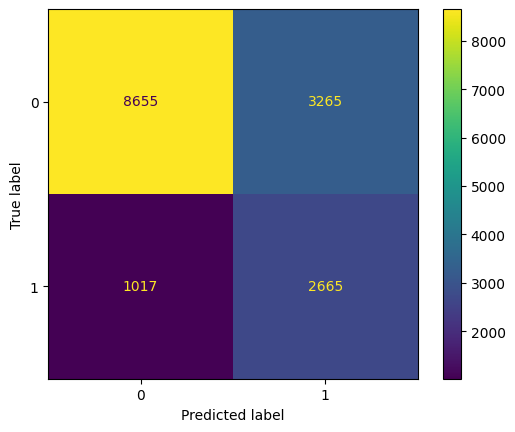

In [49]:
# Decision Tree con SMOTE

# Modelo
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced')

# Entrenar modelo
dt.fit(X_train_res, Y_train_res)

# Predicciones
y_pred = dt.predict(X_test_scaled)
y_proba = dt.predict_proba(X_test_scaled)[:, 1]

# Metricas
f1 = f1_score(Y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(Y_test, y_proba)

print("F1-score (canceladas):", f1)
print("ROC AUC:", roc_auc)

print(classification_report(Y_test, y_pred, digits=4))

# Matriz de confusion
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [50]:
evaluar_modelo(
    nombre='Decision Tree SMOTE',
    y_test=Y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    resultados=resultados)

##### 10. Comparar modelos

In [51]:
df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(by='F1_canceladas', ascending=False).round(4)

,Modelo,F1_canceladas,Recall_canceladas,Precision_canceladas,ROC_AUC
7,Random Forest SMOTE,0.6183,0.6266,0.6102,0.8440
6,Random Forest,0.5825,0.5035,0.6908,0.8441
8,Decision Tree,0.5588,0.7303,0.4525,0.8440
9,Decision Tree SMOTE,0.5545,0.7238,0.4494,0.8440
1,Regresión logística SMOTE,0.5390,0.6342,0.4687,0.7683
0,Regresión logística,0.5390,0.6342,0.4687,0.7683
2,SVM Lineal,0.5275,0.7197,0.4163,0.7683
3,SVM Lineal SMOTE,0.5211,0.7189,0.4086,0.7683
5,Naive Bayes SMOTE,0.3055,0.2450,0.4058,0.6891
4,Naive Bayes,0.3055,0.2450,0.4058,0.6891


##### 11. Seleccionar los mejores parametros mediante GridSearch para SVM, Random Forest y Decision Tree

In [66]:
# ===========================
# 1. SVM
# ===========================
svm_model = SVC(class_weight='balanced', probability=True, random_state=42)

# Definir grid de hiperparámetros
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    scoring='f1',           # F1-score para clase minoritaria
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenar
svm_grid.fit(X_train_scaled, Y_train)

print("SVM - Mejores hiperparámetros:", svm_grid.best_params_)
print("SVM - Mejor F1 CV:", svm_grid.best_score_)

# Predicciones y métricas con test
y_pred_svm = svm_grid.best_estimator_.predict(X_test_scaled)
y_prob_svm = svm_grid.best_estimator_.predict_proba(X_test_scaled)[:,1]

print(classification_report(Y_test, y_pred_svm, digits=4))
print("ROC AUC SVM:", roc_auc_score(Y_test, y_prob_svm))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

In [49]:
# ===========================
# 2. Random Forest
# ===========================
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 10, 50],
    'max_features': ['sqrt', 'log2', None]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_res, Y_train_res)

print("RF - Mejores hiperparámetros:", rf_grid.best_params_)
print("RF - Mejor F1 CV:", rf_grid.best_score_)

y_pred_rf = rf_grid.best_estimator_.predict(X_test_scaled)
y_prob_rf = rf_grid.best_estimator_.predict_proba(X_test_scaled)[:,1]

print(classification_report(Y_test, y_pred_rf, digits=4))
print("ROC AUC RF:", roc_auc_score(Y_test, y_prob_rf))

Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\conda_envs\reto06_VerdeOscuro\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [51]:
# ===========================
# 3. Decision Tree
# ===========================
dt_model = DecisionTreeClassifier()

dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 10, 50, 100],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_res, Y_train_res)

print("DT - Mejores hiperparámetros:", dt_grid.best_params_)
print("DT - Mejor F1 CV:", dt_grid.best_score_)

y_pred_dt = dt_grid.best_estimator_.predict(X_test_scaled)
y_prob_dt = dt_grid.best_estimator_.predict_proba(X_test_scaled)[:,1]

print(classification_report(Y_test, y_pred_dt, digits=4))
print("ROC AUC DT:", roc_auc_score(Y_test, y_prob_dt))

Fitting 3 folds for each of 32 candidates, totalling 96 fits
DT - Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1}
DT - Mejor F1 CV: 0.8026164714037735
              precision    recall  f1-score   support

           0     0.8634    0.8307    0.8468     11920
           1     0.5119    0.5747    0.5415      3682

    accuracy                         0.7703     15602
   macro avg     0.6876    0.7027    0.6941     15602
weighted avg     0.7805    0.7703    0.7747     15602

ROC AUC DT: 0.704363851532396


##### 12. Extraer patrones de Regresion Logística

In [ ]:
# Aunque modelos como Random Forest o SVM ofrecen mejores métricas predictivas, la regresión logística se ha utilizado para identificar los factores que influyen en la cancelación, 
# debido a su alta interpretabilidad. De esta forma se combina capacidad predictiva y análisis explicativo, alineándose con los objetivos del reto.

In [32]:
coef = pd.Series(modelo_reg_log.coef_[0], index=X_train_scaled.columns).sort_values(key=abs, ascending=False)
print(coef)

rate_type_Mid Stay                                    -2.966351
business_segment_Travel Individual                     1.814393
rate_type_Non Refundable                              -1.465025
business_segment_Leisure Individual                    1.440698
business_segment_Business Individual                   1.314209
origin_email                                           0.886148
business_segment_Mid Stay                              0.811468
ciudad_Córdoba                                         0.811424
requested_category_Three bedroom apartment superior   -0.783451
ciudad_Donosti                                         0.703587
business_segment_Travel Group                         -0.654614
origin_telephone                                       0.616377
product_count                                         -0.568492
requested_category_Hostel room                        -0.542548
lenght_of_stay                                         0.516301
lead_time                               

In [31]:
coef = modelo_reg_log.coef_[0]
features = X_train_scaled.columns

odds_ratios = pd.Series(
    np.exp(coef),
    index=features
).sort_values(ascending=False)

print(odds_ratios)

business_segment_Travel Individual                     6.137351
business_segment_Leisure Individual                    4.223643
business_segment_Business Individual                   3.721805
origin_email                                           2.425768
business_segment_Mid Stay                              2.251210
ciudad_Córdoba                                         2.251111
ciudad_Donosti                                         2.020988
origin_telephone                                       1.852204
lenght_of_stay                                         1.675818
lead_time                                              1.638138
ciudad_Granada                                         1.527397
origin_in_person                                       1.474823
business_segment_MICE Individual                       1.457404
total_adr                                              1.355288
requested_category_Studio                              1.337551
ciudad_Vitoria                          